# 1. Importación

Carga de las librerías necesarias y del dataset resultante de `01_eda.ipynb`, ya limpio (`data/processed/mallorca/listings_full_clean.csv`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/mallorca/listings_full_clean.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_license
0,1273823517224415510,https://www.airbnb.com/rooms/1273823517224415510,20260623040707,2026-06-23,city scrape,Son Pere Genet,ETV 411 Recharge your batteries in this wonder...,https://a0.muscache.com/pictures/miso/Hosting-...,651077862,https://www.airbnb.com/users/show/651077862,...,5.00,4.86,4.86,Spain - National registration number<br />ESFC...,1,1,0,0,0.47,True
1,1151380048474115597,https://www.airbnb.com/rooms/1151380048474115597,20260623040707,2026-06-23,city scrape,Ca Na Reieta by Vintage Travel,Ground Floor: Open plan living/dining room (TV...,https://a0.muscache.com/pictures/prohost-api/H...,565714005,https://www.airbnb.com/users/show/565714005,...,NaN,NaN,NaN,Mallorca - Regional registration number<br />E...,40,40,0,0,0.00,True
2,1430444173039950930,https://www.airbnb.com/rooms/1430444173039950930,20260623040707,2026-06-23,city scrape,Villa Sofía,Vacation villa for 8 people with fenced pool a...,https://a0.muscache.com/pictures/miso/Hosting-...,29095214,https://www.airbnb.com/users/show/29095214,...,NaN,NaN,NaN,Spain - National registration number<br />ESFC...,24,24,0,0,0.00,True
3,1071698089211240769,https://www.airbnb.com/rooms/1071698089211240769,20260623040707,2026-06-23,city scrape,Villa Cuxach de N'Alba By SunVillas Mallorca,Villa Cuxach de n'Alba is a completely renovat...,https://a0.muscache.com/pictures/prohost-api/H...,21160030,https://www.airbnb.com/users/show/21160030,...,4.92,4.50,4.42,Spain - National registration number<br />ESFC...,57,57,0,0,0.46,True
4,674382966270143525,https://www.airbnb.com/rooms/674382966270143525,20260623040707,2026-06-23,city scrape,Villa Menorca,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,66176030,https://www.airbnb.com/users/show/66176030,...,3.80,4.60,4.20,Spain - National registration number<br />ESFC...,159,159,0,0,0.14,True


## 2. Selección de variables de partida

De las 77 columnas del dataset limpio, decidir cuáles se descartan antes de construir features (identificadores, URLs, texto libre sin procesar, columnas redundantes dentro de una misma familia) y cuáles se mantienen como base. Mismo criterio que en las otras cinco ciudades.

Se descartan seis grupos de columnas antes de construir ninguna feature:

1. **URLs y metadatos de scraping**: `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`, `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`. No describen el alojamiento.
2. **Texto libre sin procesar**: `name`, `description`, `host_about`, `host_location`. `amenities` es distinto: se trata aparte en la sección 9 (flags por palabra clave), no se descarta aquí.
3. **Columnas que ya cumplieron su función**: `bathrooms_text` (ya se extrajo `bathrooms`), `license` (ya existe `has_license`), `host_name` (identificador) y `host_listings_count` (redundante con `calculated_host_listings_count`).
4. **`price_quote_*`**: se comprueba a continuación por qué se descartan.
5. **Familias redundantes** detectadas en la EDA: variantes de `minimum_nights`/`maximum_nights`, de `availability`, y las ventanas de reviews más finas (`number_of_reviews_l30d`, `number_of_reviews_ly`).
6. **`estimated_revenue_l365d`**: riesgo de fuga de información, se comprueba también a continuación.

Igual que en Málaga, aquí no hay ningún grupo de "distrito" que descartar en esta fase: Mallorca no trae `neighbourhood_group_cleansed` (visto en la EDA), así que la única columna geográfica de partida es `neighbourhood_cleansed` (53 municipios).

#### ¿Por qué se descarta `price_quote_*`?

`price_quote_price_per_night` coincide exactamente con `price` en todas las filas, y `price_quote_raw` es el JSON de esa misma cotización. No es información nueva.

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(1.0)

#### ¿Por qué se descarta `estimated_revenue_l365d`?

Se calcula multiplicando `price` por `estimated_occupancy_l365d`. Usarla como feature sería fuga de información.

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999857933)

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Texto libre sin estructura: la parte objetiva (tamaño, ubicación, equipamiento) ya está en columnas estructuradas, y sacar señal de texto de verdad requeriría NLP para un beneficio incierto. Se descartan de forma definitiva, igual que en las otras cinco ciudades.

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(11044, 42)

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_license']

Quedan 42 columnas de partida — exactamente las mismas que en Málaga, por no tener `neighbourhood_group_cleansed`. `id`, `host_id` y `host_profile_id` se mantienen como identificadores de referencia. `amenities` se deja para la sección 9. El resto son las que se transforman en las siguientes secciones.

## 3. Transformaciones numéricas

Logaritmos y ratios sobre las variables numéricas con distribución muy asimétrica y sobre las variables de tamaño.

### 3.1 Logaritmos

En la EDA se midió la asimetría de cada variable numérica. Se aplica `log1p` a las que tienen un coeficiente de asimetría alto.

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

df[log_vars].skew().sort_values(ascending=False)

reviews_per_month                 14.733060
number_of_reviews                 12.043253
number_of_reviews_ltm             10.823640
price                              6.709139
calculated_host_listings_count     3.133428
bathrooms                          1.842687
beds                               1.740228
bedrooms                           1.263736
dtype: float64

In [8]:
for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

`reviews_per_month` (14,7) y `number_of_reviews`/`number_of_reviews_ltm` (12,0/10,8) encabezan con diferencia — asimetrías bastante más altas que en Málaga (2,3-3,2): en un mercado tan estacional, la mayoría de anuncios acumula pocas reseñas y un grupo pequeño (los apartamentos urbanos de rotación rápida) concentra volúmenes muy superiores. `price` (6,7) queda más moderada, sin ningún artefacto extremo que la dispare (visto en la EDA, sección 8).

Se comprueba el efecto sobre `price`, la más asimétrica de las variables clave del modelo.

Text(0.5, 1.0, 'price_log')

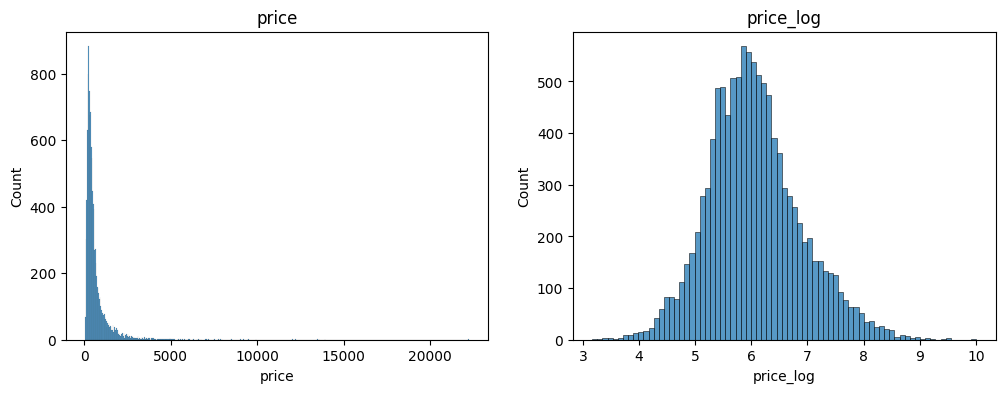

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")

La distribución pasa de una cola larga (todavía marcada por las villas de lujo) a una forma mucho más cercana a la normal, igual que en las otras cinco ciudades.

### 3.2 Ratios

`price_per_accommodate` normaliza el precio por la capacidad del alojamiento. Se usa `accommodates` como denominador porque nunca vale 0. `price_per_min_night` es el mismo ratio de siempre.

In [10]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,11044.000000,11044.000000
mean,106.420603,419.956356
std,105.192284,777.727600
min,5.705625,0.756000
25%,54.949063,78.000000
50%,77.031500,182.053750
75%,113.241250,417.000000
max,2261.905000,22260.000000


<Axes: xlabel='price_per_accommodate', ylabel='Count'>

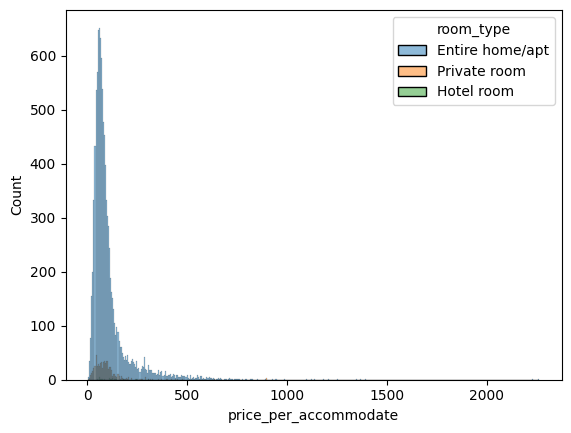

In [11]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")

## 4. Variables de tamaño: multicolinealidad

`accommodates`, `bedrooms`, `beds` y `bathrooms` están correlacionadas entre sí. Decidir si se mantienen todas, se combinan en un índice, o se descarta alguna.

In [12]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]
df[size_vars].corr()

,accommodates,bedrooms,beds,bathrooms
accommodates,1.000000,0.922011,0.842784,0.802153
bedrooms,0.922011,1.000000,0.853432,0.816587
beds,0.842784,0.853432,1.000000,0.713475
bathrooms,0.802153,0.816587,0.713475,1.000000


Correlaciones entre 0,71 y 0,92 — sensiblemente más altas que en cualquiera de las otras cinco ciudades. Se calcula el VIF (Variance Inflation Factor): a partir de 5, y sobre todo de 10, se considera multicolinealidad seria.

In [13]:
corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    7.572211
bedrooms        8.550646
beds            3.987404
bathrooms       3.154663
Name: VIF, dtype: float64

**El VIF más alto de las seis ciudades, con diferencia**: `bedrooms` (8,55) y `accommodates` (7,57) rozan el umbral de 10, muy por encima del rango 1,8-3,8 visto en Sevilla (la ciudad más alta hasta ahora). Tiene sentido en un mercado de villas: el tamaño de una villa (dormitorios, camas, baños, aforo) escala de forma mucho más rígida y conjunta que el de un piso urbano, donde hay más combinaciones sueltas (un piso de 1 dormitorio con 2 baños, un estudio con sofá-cama...). `beds` (3,99) y `bathrooms` (3,15) quedan más moderadas.

Se mantienen las cuatro tal cual, sin combinarlas ni descartar ninguna — para un modelo de árboles (el que gana en las otras cinco ciudades) la multicolinealidad no es un problema. Pero queda marcado como el punto más delicado de Mallorca para el baseline lineal de `03_model_baseline.ipynb`: si los coeficientes de estas cuatro variables salen inestables entre folds, la causa más probable es esta.

## 5. Codificación de categóricas

`room_type`, `neighbourhood_cleansed` y `property_type`: agrupar categorías raras donde haga falta y codificar.

### 5.1 `room_type`

3 categorías sin orden natural (`Entire home/apt`, `Private room`, `Hotel room`): one-hot encoding.

In [14]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_cleansed`: municipio y "barrio" a la vez

Igual que en Málaga, Mallorca solo trae una columna geográfica: `neighbourhood_cleansed`, aquí con 53 valores (los 53 municipios de la isla, ver EDA sección 6.1). Con 53 categorías, un one-hot directo sigue siendo manejable — no hace falta agrupar nada. Se construyen **las dos representaciones a partir de la misma columna**:

- `district_*` (one-hot, 53 columnas): para que el modelo y el resto de la app (que ya asume una familia `district_*` para el desplegable de distrito, el mapa por zonas, etc.) funcionen igual que en las otras ciudades de geografía plana.
- `neighbourhood_price_encoded` (target encoding suavizado): para el desplegable de "barrio" de la app y el resto de la lógica que ya asume esa columna.

Al venir las dos de la misma columna, `neighbourhood_price_encoded` no aporta aquí información estadística que los 53 dummies de `district_*` no tengan ya. Se mantiene igualmente por consistencia con el resto de la app.

In [15]:
df["district"] = df["neighbourhood_cleansed"]
df = pd.get_dummies(df, columns=["district"], prefix="district")

**Aviso importante**: el target encoding de abajo se calcula con todo el dataset, solo para tener la columna disponible y poder seguir explorando en el resto de este notebook — no es la versión final. Antes de entrenar un modelo de verdad hay que recalcularla usando únicamente los datos de entrenamiento, o se estaría filtrando información del conjunto de test al de entrenamiento. Por eso `neighbourhood_cleansed` (la columna cruda) se mantiene más allá de la limpieza final de la sección 10: la corrección real ocurre en `03_model_baseline.ipynb`, justo después del split.

In [16]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [17]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False)

,neighbourhood_cleansed,neighbourhood_price_encoded
88,Andratx,1089.490292
59,Esporles,1075.211090
99,Algaida,957.263171
54,Marratxí,918.300140
215,Santa María del Camí,908.485404
171,Alaró,812.223903
280,Mancor de la Vall,797.470262
142,Son Servera,794.418965
42,Santa Eugènia,789.020551
496,Deyá,785.489883


`Andratx` encabeza por precio medio (no por mediana: en la EDA, sección 9, `Marratxí` ganaba por mediana), señal de que en `Andratx` la media está más tirada hacia arriba por algunas villas de lujo muy concretas (la zona del Port d'Andratx, con algunas de las propiedades más caras de la isla) que en el resto de municipios.

### 5.3 `property_type`

54 categorías, pero muy concentradas: `Entire home` y `Entire villa` son el 59,3% del dataset, y 36 de las 54 categorías tienen menos de 30 anuncios. Igual que en las otras ciudades, interesa agrupar en "Otros" antes de codificar: tras agrupar quedan 19 categorías (18 propias + `Other`), un one-hot manejable.

In [18]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

19

In [19]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

Con esto, `room_type`, `district` (a partir de `neighbourhood_cleansed`) y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` aporta además `neighbourhood_price_encoded` como columna numérica. `property_type` (texto) se descarta en la limpieza final de la sección 10. `neighbourhood_cleansed` (texto) se mantiene hasta después del split en `03_model_baseline.ipynb`.

## 6. Variables derivadas del host

Señales sobre el tipo de host a partir de `calculated_host_listings_count`, `host_is_superhost` y la antigüedad.

### 6.1 Antigüedad del host

In [20]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    11044.000000
mean         7.909061
std          3.687247
min          0.000000
25%          5.083333
50%          9.083333
75%         10.166667
max         15.416667
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

Antes de convertir `calculated_host_listings_count` en un flag binario, se comprueba qué umbral tendría sentido.

In [21]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 76.6%
más de 2 anuncios: 68.8%
más de 5 anuncios: 58.1%
más de 10 anuncios: 48.9%


Con `> 1` ya se marca al 76,6% como "profesional" (la mediana de `calculated_host_listings_count` es 10, la más alta de las seis ciudades — Mallorca es, con diferencia, el mercado más dominado por hosts con carteras grandes, visto ya en la EDA). Un flag binario no distingue lo suficiente. Se construyen las mismas 4 categorías que en las otras ciudades, por umbrales redondos: `individual` (1 anuncio), `pequeno` (2-10), `mediano` (11-50) y `grande` (51+).

In [22]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,2581,359.60
pequeno,3062,285.40
mediano,2121,416.75
grande,3280,546.90


No monótona (359,60€ → 285,40€ → 416,75€ → 546,90€), con el mismo bache en `pequeno` que ya aparecía en Valencia/Málaga. Se prefiere no asumir un orden numérico limpio y se codifica con one-hot.

In [23]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

`calculated_host_listings_count_entire_homes` frente al total del host: qué proporción de los anuncios de ese host son alojamientos completos.

In [24]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.11174957720654731)

**Al revés que en las demás ciudades**: la correlación de `host_entire_homes_ratio` (0,11) es más *baja* que la del propio `calculated_host_listings_count` (0,37), no más alta. En Mallorca casi todos los anuncios ya son `Entire home/apt` (93,8%, visto en la EDA), así que "qué proporción de la cartera es alojamiento completo" apenas distingue entre hosts — mientras que "cuántos anuncios tiene" sigue siendo un proxy fuerte de que se trata de una gestora grande especializada en villas de más valor.

## 7. Variables derivadas de reviews

Señales a partir de `review_scores_rating` y compañía, teniendo en cuenta que una parte de los anuncios no tiene reviews todavía.

### 7.1 `has_reviews`

Se deja explícito con un flag.

In [25]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     9194
False    1850
Name: count, dtype: int64

El 16,8% de los anuncios no tiene reviews todavía — más del doble que en Málaga (9,0%), coherente con un mercado más estacional donde una parte relevante de las villas se publicó recientemente o abre solo temporada alta.

### 7.2 Antigüedad y recencia de reviews

Se usa la `last_review` más reciente de todo el dataset como fecha de referencia ('hoy' aproximado).

In [26]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,9194.000000,9194.000000
mean,1779.943441,199.818577
std,1209.346723,389.777937
min,10.000000,0.000000
25%,749.000000,23.000000
50%,1565.500000,40.000000
75%,2655.750000,271.000000
max,5442.000000,4272.000000


In [27]:
df["listing_age_days"].corr(df["price"]), df["days_since_last_review"].corr(df["price"])

(np.float64(-0.05688528354781725), np.float64(0.09599183910940692))

Ambas quedan `NaN` para los anuncios sin reviews, coherente con `has_reviews`. La correlación con `price` es débil en las dos (-0,06 y 0,10), similar a las otras ciudades, pero se mantienen igualmente: son información real que antes estaba encerrada en un texto de fecha.

### 7.3 Los 6 subscores de review

Correlacionan entre 0,57 y 0,84 con `review_scores_rating`, y tienen prácticamente los mismos nulos. Misma redundancia que ya se resolvió con las familias de la sección 2: se conserva `review_scores_rating` como resumen y se descartan los 6 subscores.

In [28]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

`review_scores_rating` se deja como `NaN` para los anuncios sin reviews, sin imputar: en la EDA correlaciona con `price` de forma casi nula y ligeramente negativa (-0,03), inventar un valor no aportaría nada.

## 8. Variables geográficas

Alguna codificación adicional de `latitude`/`longitude` más allá del municipio.

### 8.1 Distancia a Palma

A diferencia de una ciudad, Mallorca no tiene un único "centro" evidente. Se usa Palma (la Catedral, `39.5673, 2.6474`) como punto de referencia por ser la capital, el principal núcleo urbano y donde están el aeropuerto y el puerto — el hub natural de la isla, igual en espíritu a como las otras ciudades usan su plaza histórica.

In [29]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat, center_lon = 39.5673, 2.6474  # Catedral de Palma (La Seu)
df["distance_to_center_km"] = haversine(df["latitude"], df["longitude"], center_lat, center_lon)

df["distance_to_center_km"].describe()

count    11044.000000
mean        39.511643
std         17.543011
min          0.109030
25%         25.976325
50%         46.467796
75%         52.153365
max         72.596991
Name: distance_to_center_km, dtype: float64

In [30]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"])

(np.float64(-0.0017286732308439711), np.float64(0.020591741000109208))

**Ni rastro de patrón lineal, en ninguna dirección** (-0,002 con `price`, 0,02 con `neighbourhood_price_encoded`) — muy distinto de Málaga, donde la distancia al centro sí correlacionaba con fuerza (0,62) con el precio del barrio. La razón está en la EDA (sección 9): la relación aquí no es monótona. Palma (distancia 0) es barata; los municipios más caros (Andratx, Esporles, Marratxí) están a una distancia intermedia (20-40km, la costa exclusiva de la Tramuntana); y los municipios más baratos después de Palma (Pollença, Alcúdia) están más lejos todavía (50-70km) pero son zonas de turismo masivo con muchos apartamentos, no villas. Una sola distancia en línea recta no puede capturar esta forma de "U": cerca es barato, a media distancia es caro, lejos vuelve a ser barato. Se mantiene la variable de todos modos — un modelo de árboles sí puede aprovechar esta no linealidad, aunque la correlación lineal no la vea.

Text(0, 0.5, 'log1p(price)')

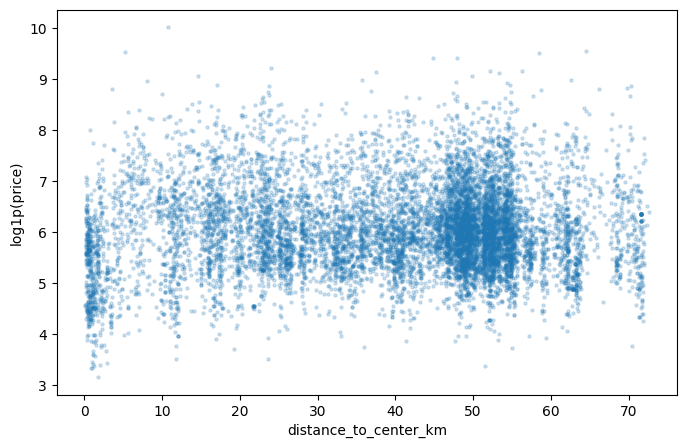

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(df["distance_to_center_km"], np.log1p(df["price"]), s=5, alpha=0.2)
plt.xlabel("distance_to_center_km")
plt.ylabel("log1p(price)")

La nube de puntos confirma la lectura: no hay ninguna tendencia lineal visible, a diferencia de cualquiera de las otras cinco ciudades.

### 8.2 Densidad de anuncios cercanos

Motivado en la sección 11.5 de la EDA: cuántos otros anuncios reales hay en un radio de 150 metros de cada uno.

In [32]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    11044.000000
mean         6.117168
std          8.052488
min          0.000000
25%          1.000000
50%          3.000000
75%          8.000000
max         53.000000
Name: n_nearby_150m, dtype: float64

In [33]:
df["n_nearby_150m"].corr(df["price"])

np.float64(-0.12870681243167093)

Correlación débil pero negativa (-0,13), consistente con la EDA: más anuncios cercanos suele significar zona de apartamentos de turismo masivo (barata), no zona prime — al revés de lo que pasa en el centro histórico de una ciudad. A diferencia de `distance_to_center_km`, aquí sí hay algo de señal lineal aprovechable.

## 9. Amenities

Se construyen las cuatro variables motivadas en la sección 12 de la EDA: `has_ac`, `has_pool`, `has_sea_view` (flags por palabra clave) y `n_amenities` (recuento total). Un one-hot directo de las más de 2000 categorías de `amenities` no es viable (más de la mitad son variantes que aparecen una sola vez).

### 9.1 Parsear y construir los flags

In [34]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)

def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition"]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"]))
df["has_sea_view"] = amenities_parsed.apply(lambda l: has_any(l, ["sea view", "ocean view"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_sea_view", "n_amenities"]].describe()

,n_amenities
count,11044.000000
mean,38.772999
std,15.726829
min,0.000000
25%,29.000000
50%,37.000000
75%,49.000000
max,98.000000


Prevalencias consistentes con la EDA (`has_ac` ~72,5%, `has_pool` ~69,8%, `has_sea_view` ~12,1%, `n_amenities` media ~38,8). `has_pool` es, con diferencia, la más frecuente de las cuatro ciudades donde se ha probado esta variable — reflejo directo del peso de las villas — mientras que `has_sea_view` es una variable inédita en el proyecto, propia de un mercado insular.

### 9.2 Descartar `amenities`

Ya cumplió su función: se descarta el texto crudo.

In [35]:
df = df.drop(columns=["amenities"])
df.shape

(11044, 135)

## 10. Dataset final para modelado

Selección de las columnas finales y guardado en `data/processed/mallorca/` para los notebooks de modelado.

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

En la sección 6 se combinó la antigüedad como host, pero se quedó sin tocar la antigüedad como usuario de Airbnb en general. Se combina igual, por coherencia.

In [36]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

Se descartan las columnas ya sustituidas por una versión mejor: `property_type` en texto, las cuatro columnas de antigüedad ya combinadas, `first_review`/`last_review` en formato fecha, y el desglose `calculated_host_listings_count_entire_homes`/`_private_rooms`/`_shared_rooms` (ya resumido en `host_entire_homes_ratio`).

`neighbourhood_cleansed` es la excepción, no se descarta aquí: se mantiene para que `03_model_baseline.ipynb` recalcule `neighbourhood_price_encoded` solo con train justo después del split.

In [37]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=final_drop)
df.shape

(11044, 126)

### 10.3 Comprobación de nulos

Debería quedar solo lo que se dejó así a propósito: todo lo relacionado con anuncios sin reviews todavía.

In [38]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      1850
listing_age_days          1850
days_since_last_review    1850
dtype: int64

Las tres coinciden exactamente en las mismas 1.850 filas (`has_reviews == False`), tal y como se esperaba. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

`id`, `host_id` y `host_profile_id` son referencias, no entran como input del modelo; `price` es la variable objetivo; `neighbourhood_cleansed` viaja en el CSV pero todavía no es una feature (pendiente de la corrección de fuga en `03_model_baseline.ipynb`); el resto son las features.

In [39]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 121


126 columnas en total: 3 identificadores, 1 objetivo, 1 pendiente y **121 features** — muchas más que en cualquier otra ciudad, casi enteramente por `district_*`: 53 municipios en vez de los 11-19 distritos de las demás. Es una geografía plana como la de Málaga, pero con casi 5 veces más categorías.

### 10.5 Exportar

In [40]:
df.to_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/mallorca/listings_full_features.csv", index=False)